# PCA-Based Anomaly Detection on Semiconductor Manufacturing Data
**Author:** Shirsha Pattanaik  
**Dataset:** SECOM — UCI Machine Learning Repository  
**Goal:** Detect manufacturing anomalies using PCA reconstruction error (SPE),
benchmarked against Isolation Forest and One-Class SVM.

## 0. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
np.random.seed(42)

## 1. Data Loading & Preprocessing

In [3]:
# URLs for SECOM dataset
url_data = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
url_labels = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

# Load features and labels
df = pd.read_csv(url_data, sep=" ", header=None)
labels = pd.read_csv(url_labels, sep=" ", header=None)[0].values

X_raw = df.values.astype(float)

# Feature names
feature_names = [f"Feature_{i}" for i in range(df.shape[1])]

# Convert to DataFrame for easier analysis
df = pd.DataFrame(X_raw, columns=feature_names)

print("Dataset loaded successfully.\n")

print("DATASET INFORMATION:")
print(f"Number of samples   : {X_raw.shape[0]}")
print(f"Number of features  : {X_raw.shape[1]}")
print(f"Labels shape        : {labels.shape}")


Dataset loaded successfully.

DATASET INFORMATION:
Number of samples   : 1567
Number of features  : 590
Labels shape        : (1567,)


In [4]:
normal_mask = labels == -1
fault_mask = labels == 1

X_normal = X_raw[normal_mask]
X_fault = X_raw[fault_mask]

print("NORMAL VS FAULT SAMPLES:")

print("Normal samples shape :", X_normal.shape)
print("Fault samples shape  :", X_fault.shape)



print("MISSING VALUE HANDLING:")

# Percentage of missing values per feature
missing_ratio = np.isnan(X_raw).mean(axis=0)

# Keep only columns with less than 50% missing values
keep = missing_ratio < 0.5

X_clean = X_raw[:, keep]
print(f"Original number of features : {X_raw.shape[1]}")
print(f"Remaining features          : {X_clean.shape[1]}")

# Mean imputation
column_means = np.nanmean(X_clean, axis=0)
# Find missing value positions
nan_rows, nan_cols = np.where(np.isnan(X_clean))
# Replace NaNs with column means
X_clean[nan_rows, nan_cols] = column_means[nan_cols]

print("Successful.")

NORMAL VS FAULT SAMPLES:
Normal samples shape : (1463, 590)
Fault samples shape  : (104, 590)
MISSING VALUE HANDLING:
Original number of features : 590
Remaining features          : 562
Successful.


## 2. Train-Test Split

In [5]:
print("TRAIN-TEST SPLIT:")

n_samples = len(labels)
# 70% train, 30% test
split_index = int(0.7 * n_samples)
train_mask = (np.arange(n_samples) < split_index) & (labels == -1)

# Test on remaining samples
test_mask = np.arange(n_samples) >= split_index

X_train = X_clean[train_mask]
X_test = X_clean[test_mask]
y_test = (labels[test_mask] == 1).astype(int)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

TRAIN-TEST SPLIT:
Training samples : 1018
Testing samples  : 471


## 3. Feature Scaling

In [6]:

#FEATURE SCALING (StandardScaler)
print("FEATURE SCALING:")

scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform datasets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

FEATURE SCALING:
Feature scaling completed.


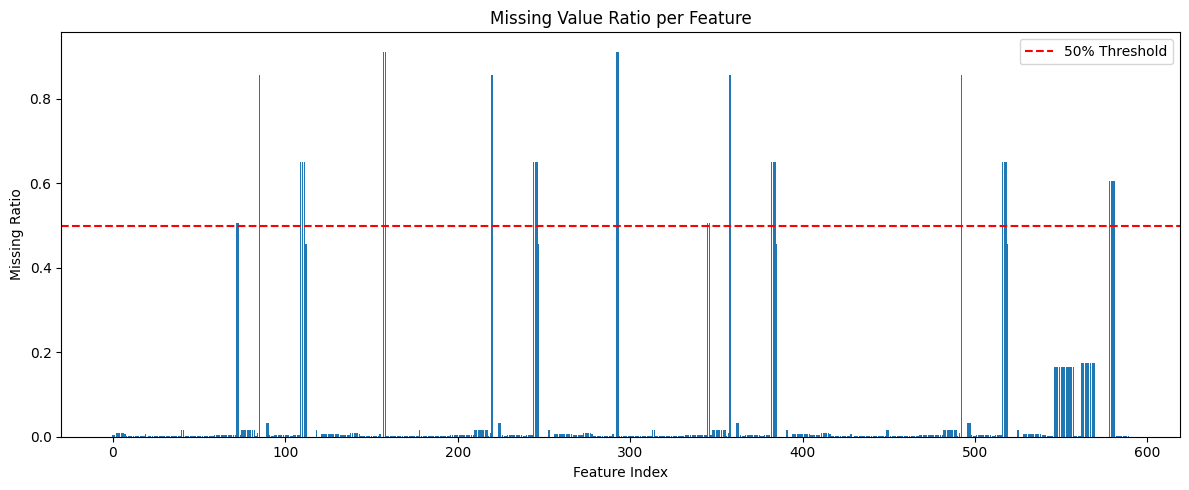

In [7]:

# Plot 1: Missing Values Percentage-

plt.figure(figsize=(12, 5))

plt.bar(range(len(missing_ratio)), missing_ratio)

plt.axhline(
    y=0.5,
    color='red',
    linestyle='--',
    label='50% Threshold'
)

plt.title("Missing Value Ratio per Feature")
plt.xlabel("Feature Index")
plt.ylabel("Missing Ratio")
plt.legend()

plt.tight_layout()
plt.show()

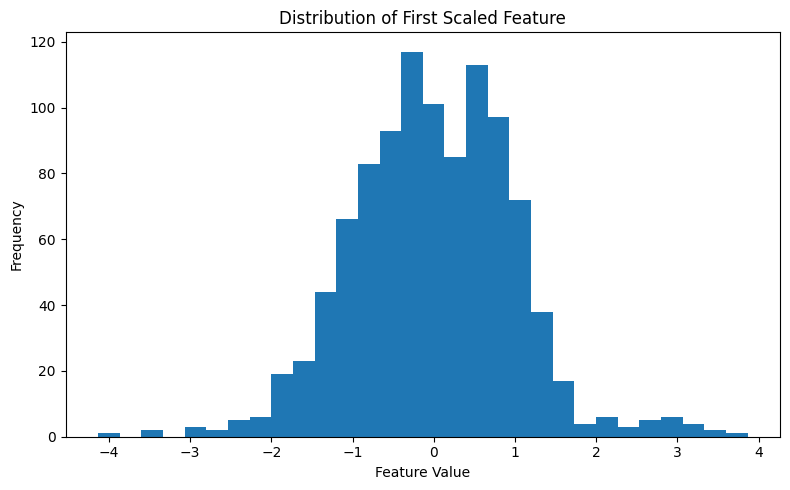

In [8]:

# Plot 2: Feature Distribution (First Feature Example)

plt.figure(figsize=(8, 5))

plt.hist(
    X_train_scaled[:, 0],
    bins=30
)

plt.title("Distribution of First Scaled Feature")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

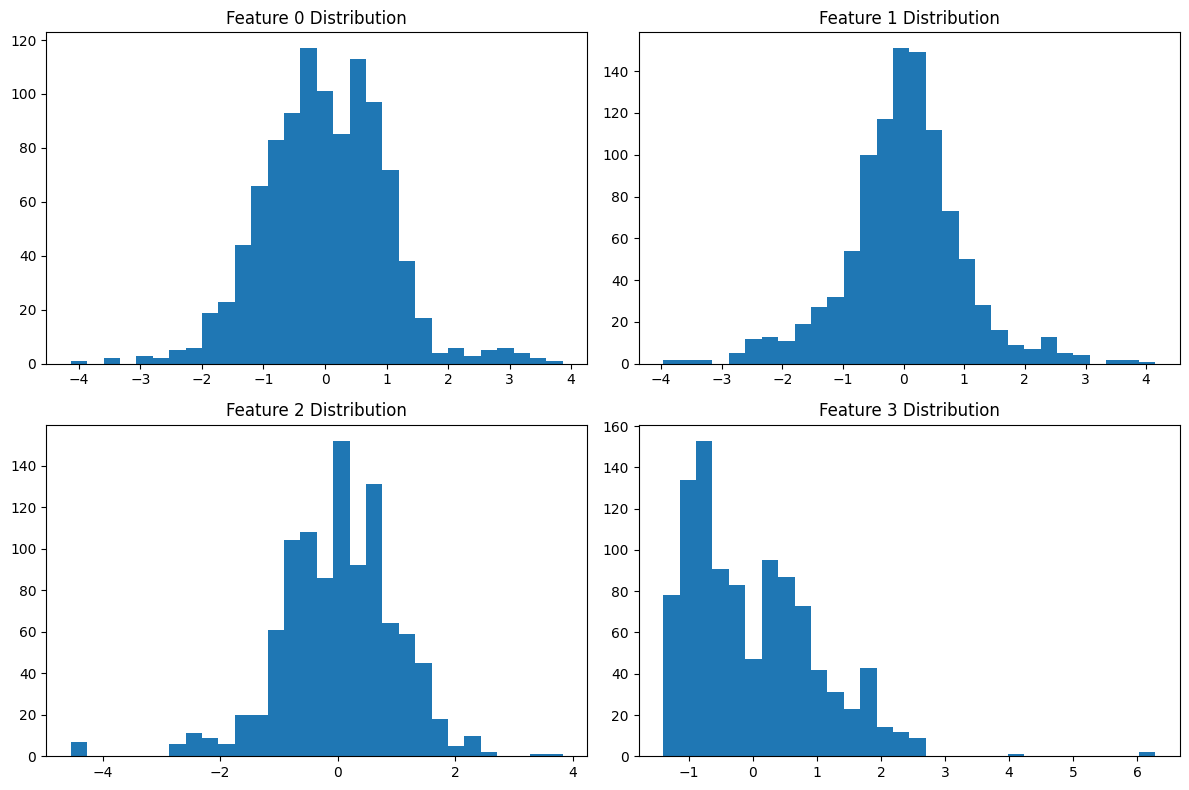

In [9]:

# Plot 3: Multiple Feature Distributions

num_features_to_plot = 4

plt.figure(figsize=(12, 8))

for i in range(num_features_to_plot):

    plt.subplot(2, 2, i + 1)

    plt.hist(
        X_train_scaled[:, i],
        bins=30
    )

    plt.title(f"Feature {i} Distribution")

plt.tight_layout()
plt.show()

In [10]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)
print("y_test shape        :", y_test.shape)

print("Data preprocessing completed successfully.")
print("Dataset is ready for PCA and anomaly detection models.")

X_train_scaled shape: (1018, 562)
X_test_scaled shape : (471, 562)
y_test shape        : (471,)
Data preprocessing completed successfully.
Dataset is ready for PCA and anomaly detection models.


Pre-Processing Choices:
1. Columns with more than 50% missing values were removed
   because they contain insufficient information and may
   negatively affect model performance.

2. Mean imputation was used to replace remaining missing
   values because it is simple and preserves dataset size.

3. Chronological train-test split was applied to preserve
   temporal order and avoid data leakage.

4. Only normal samples (-1) were used for training because
   anomaly detection models learn normal behavior patterns.

5. StandardScaler was applied so that all sensor features
   have zero mean and unit variance, improving PCA performance.

# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original correlated features into a new set of uncorrelated variables called Principal Components (PCs).

Each principal component is a linear combination of the original features and captures the maximum possible variance in the data.

The first principal component captures the highest variance, the second captures the next highest variance while remaining orthogonal to the first, and so on.

Mathematically,

X → Z

where

Z = XW

Here,

- X = standardized data matrix
- W = matrix of eigenvectors
- Z = transformed PCA representation

The eigenvectors of the covariance matrix define the principal directions, and the corresponding eigenvalues indicate the amount of variance captured.

For anomaly detection, PCA is trained only on normal samples. Normal observations can be reconstructed accurately from the PCA subspace, whereas anomalous observations usually exhibit larger reconstruction errors.

## 4. PCA — Dimensionality Reduction

In [11]:
# Fit PCA using all components

pca_full = PCA()

pca_full.fit(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Total components:", len(cumulative_variance))

Total components: 562


In [12]:
# Number of components required to explain 95% variance

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 95% variance:", n_components_95)

Components required for 95% variance: 156


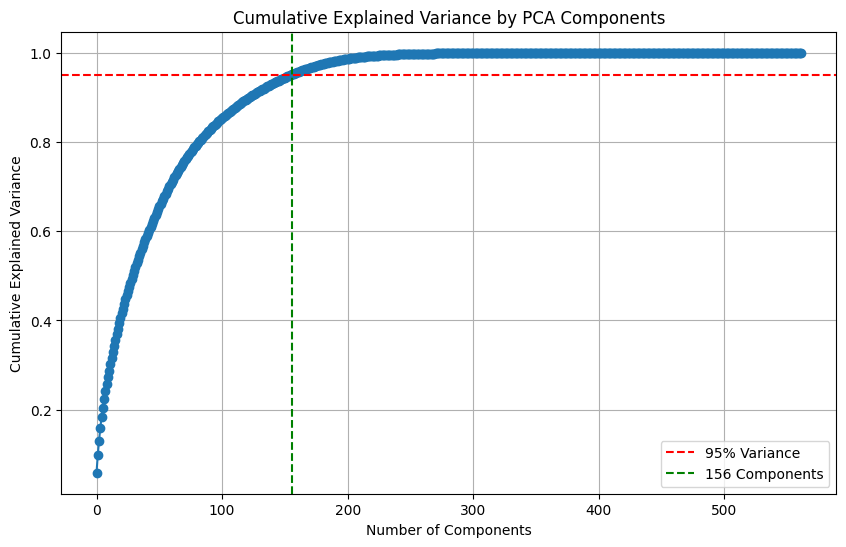

In [13]:
plt.figure(figsize=(10,6))

plt.plot(
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance'
)

plt.axvline(
    x=n_components_95,
    color='green',
    linestyle='--',
    label=f'{n_components_95} Components'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance by PCA Components")

plt.legend()

plt.grid(True)

plt.show()

In [14]:
# Final PCA model

pca = PCA(
    n_components=n_components_95
)

pca.fit(X_train_scaled)

print("PCA model trained successfully.")

PCA model trained successfully.


In [15]:
X_train_pca = pca.transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Training PCA shape:", X_train_pca.shape)
print("Testing PCA shape :", X_test_pca.shape)

Training PCA shape: (1018, 156)
Testing PCA shape : (471, 156)


# PCA Subspace and Anomaly Detection

The selected principal components define a lower-dimensional subspace called the PCA subspace.

This subspace captures the dominant patterns present in normal operating conditions.

During anomaly detection:

1. Normal observations lie close to the PCA subspace.
2. Faulty observations often contain patterns not represented by the learned subspace.
3. As a result, anomalous samples exhibit larger reconstruction errors.

Therefore, PCA can be used to distinguish normal and abnormal observations by measuring reconstruction error.

In [16]:
print("Selected Components =", n_components_95)

print(
    "Variance Captured =",
    cumulative_variance[n_components_95-1]
)

Selected Components = 156
Variance Captured = 0.9503883048593095


# Interpretation

The PCA model selected **156 principal components** to preserve at least **95% of the total variance** in the SECOM dataset.

This means that the original high-dimensional feature space can be reduced to 156 dimensions while retaining most of the information contained in the data.

The dimensionality reduction decreases computational complexity and noise while preserving the important structure of normal process behavior.

The retained PCA subspace is subsequently used for anomaly detection.

# PCA Reconstruction

Principal Component Analysis (PCA) reduces the dimensionality of data by projecting it onto a lower-dimensional subspace while preserving most of the variance. After obtaining the principal components, the data can be reconstructed back into the original feature space using the inverse transformation.

Then the Squared Prediction Error (SPE), also known as the reconstruction error, measures the difference between the original observation and its PCA reconstruction.

For each observation, the error is computed as the sum of squared differences across all features.

Formula:

$$
SPE_i = \sum_{j=1}^{p} \left(x_{ij} - \hat{x}_{ij}\right)^2
$$

where:

- $x_{ij}$ = original feature value
- $\hat{x}_{ij}$ = reconstructed feature value
- $p$ = number of features

In [17]:
# Reconstruct data from PCA space

X_train_reconstructed = pca.inverse_transform(X_train_pca)
X_test_reconstructed = pca.inverse_transform(X_test_pca)

print("Reconstruction completed.")

Reconstruction completed.


## 5. Anomaly Detection via SPE

In [18]:
# Squared Prediction Error (SPE)

def anomaly_score(X_original, X_reconstructed):
    """
    Computes Squared Prediction Error (SPE)
    for each sample.
    """

    spe = np.sum(
        (X_original - X_reconstructed) ** 2,
        axis=1
    )

    return spe

In [19]:
# Calculate SPE scores

train_scores = anomaly_score(
    X_train_scaled,
    X_train_reconstructed
)

test_scores = anomaly_score(
    X_test_scaled,
    X_test_reconstructed
)

print("Anomaly scores calculated.")


Anomaly scores calculated.


## Anomaly Detection

A threshold is selected using the 99th percentile of the training SPE scores. Observations with SPE values greater than this threshold are classified as anomalies.

Decision Rule:
- SPE ≤ Threshold → Normal
- SPE > Threshold → Anomaly

In [20]:
# Threshold based on normal training data

threshold = np.percentile(
    train_scores,
    99
)

print("99th Percentile Threshold =", threshold)

99th Percentile Threshold = 54.89677370073074


In [21]:
# Samples with SPE above threshold are anomalies

y_pred = (test_scores > threshold).astype(int)

num_anomalies = np.sum(y_pred)

print("Detected anomalies:", num_anomalies)

Detected anomalies: 159


## Distribution of SPE Scores

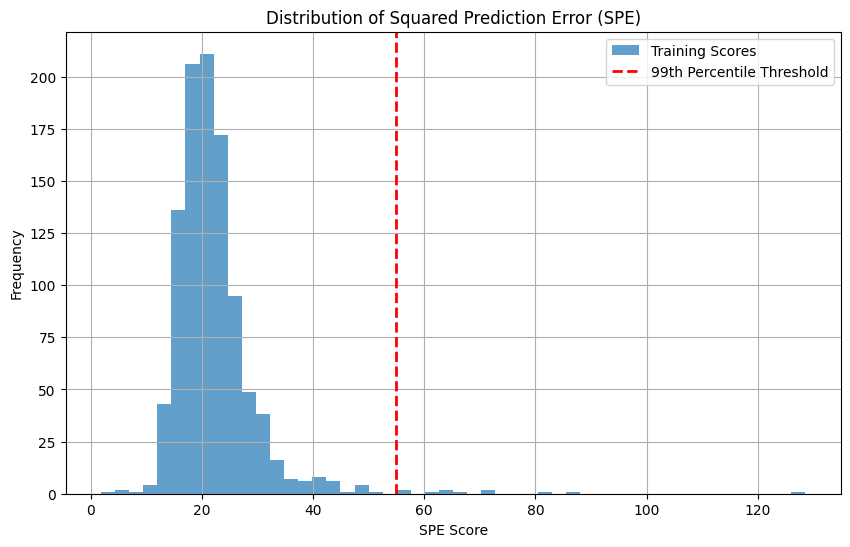

In [22]:
plt.figure(figsize=(10,6))

plt.hist(
    train_scores,
    bins=50,
    alpha=0.7,
    label="Training Scores"
)

plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='99th Percentile Threshold'
)

plt.xlabel("SPE Score")
plt.ylabel("Frequency")

plt.title("Distribution of Squared Prediction Error (SPE)")

plt.legend()

plt.grid(True)

plt.show()

## Visualization of Detected Anomalies

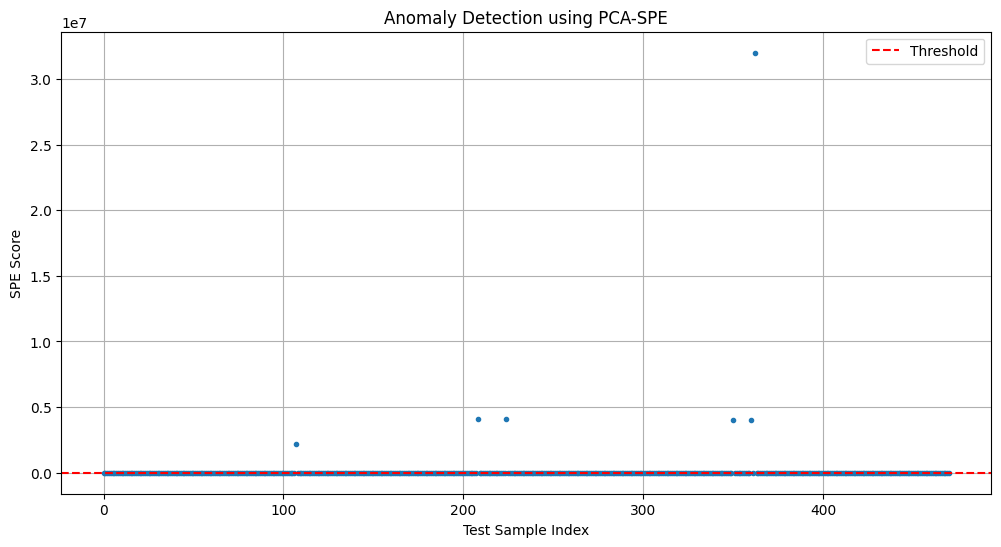

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    test_scores,
    marker='.',
    linestyle='none'
)

plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.xlabel("Test Sample Index")
plt.ylabel("SPE Score")

plt.title("Anomaly Detection using PCA-SPE")

plt.legend()

plt.grid(True)

plt.show()

## Interpretation

The PCA-SPE approach identifies anomalies based on reconstruction error. Since PCA captures the dominant structure of normal data, observations that cannot be accurately reconstructed exhibit higher SPE values.

Using the 99th percentile threshold allows the model to automatically identify extreme observations without requiring labeled anomaly examples. This makes PCA-SPE an effective unsupervised anomaly detection technique for high-dimensional datasets.

## Prediction Generation using Threshold

After computing the Squared Prediction Error (SPE) for each sample, a threshold is used to classify observations as normal or anomalous.

Samples with SPE values greater than the threshold are labeled as anomalies (1), while others are considered normal (0).

The threshold acts as a decision boundary. If the reconstruction error exceeds this limit, the sample is considered abnormal. This step converts continuous anomaly scores into binary classification outputs.
These results indicate that the current threshold selection leads to an overly sensitive model, which detects many potential anomalies but at the cost of a high false positive rate. Adjusting the threshold or improving feature representation may help achieve a better balance between precision and recall.


## Evaluation Metrics

To evaluate the performance of the anomaly detection model, we compute:
- Precision
- Recall
- F1 Score

These metrics help understand how well the model identifies anomalies.

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Precision: 0.06918238993710692
Recall   : 0.4230769230769231
F1 Score : 0.11891891891891893


## Interpretation

The model achieved a precision of 0.069, a recall of 0.423, and an F1-score of 0.119.

The low precision indicates that many samples classified as anomalies were actually normal observations. This is caused by the relatively high number of false positives.

The recall value shows that the model successfully detected approximately 42% of the actual anomalies present in the test set. While the model is capable of identifying some anomalous behavior, several anomalies remain undetected.

The low F1-score reflects the imbalance between precision and recall, suggesting that the current threshold may be too sensitive and generates excessive false alarms.

## Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

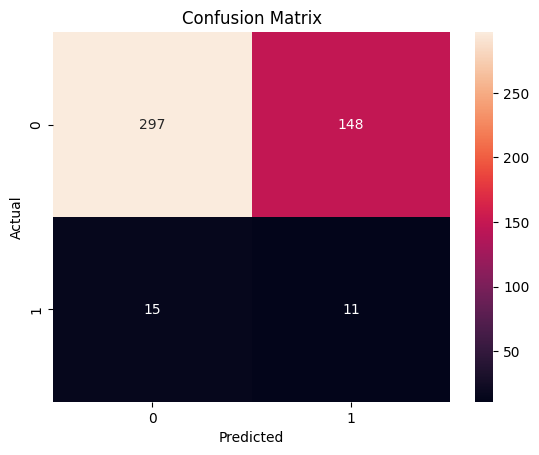

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

From the confusion matrix, the following values are observed:

True Negatives (TN) = 297

False Positives (FP) = 148

False Negatives (FN) = 15

True Positives (TP) = 11

## Interpretation

The confusion matrix shows that the model correctly classified 297 normal observations and 11 anomalous observations.

However, 148 normal observations were incorrectly classified as anomalies (false positives), while 15 anomalies were missed (false negatives).

The large number of false positives indicates that the model is highly sensitive to deviations in reconstruction error. Although this increases anomaly detection capability, it also produces many false alarms.

In practical applications, reducing false positives would improve reliability without significantly compromising anomaly detection performance.


## SPE Control Chart

The SPE control chart visualizes anomaly scores over time along with the threshold.

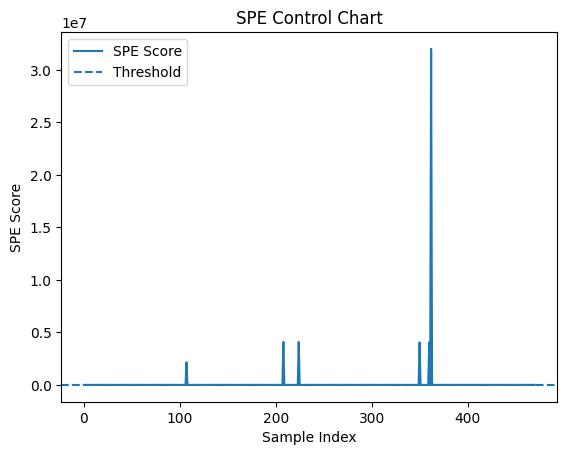

In [26]:
plt.figure()

plt.plot(test_scores, label="SPE Score")
plt.axhline(y=threshold, linestyle='--', label="Threshold")

plt.xlabel("Sample Index")
plt.ylabel("SPE Score")
plt.title("SPE Control Chart")

plt.legend()
plt.show()

## SPE Control Chart Interpretation

The SPE control chart displays the reconstruction error for each test sample together with the anomaly threshold.

Most observations have relatively small SPE values, while a number of samples exhibit large spikes above the threshold.

Samples exceeding the threshold are classified as anomalies. The presence of several spikes indicates that the PCA model successfully identifies observations that deviate significantly from normal behavior.

However, the large number of detected anomalies suggests that the threshold may be relatively sensitive, contributing to the high false positive rate observed in the evaluation metrics.

## Distribution of Anomaly Scores

A histogram is used to analyze the distribution of anomaly scores.

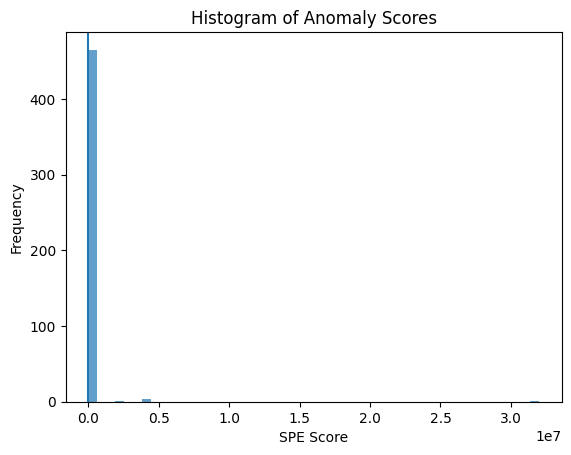

In [27]:
plt.figure()

plt.hist(test_scores, bins=50, alpha=0.7)
plt.axvline(threshold)

plt.title("Histogram of Anomaly Scores")
plt.xlabel("SPE Score")
plt.ylabel("Frequency")

plt.show()

## Interpretation

The histogram shows that most SPE values are concentrated near the lower end of the distribution, while a smaller number of observations exhibit much larger reconstruction errors.

The threshold separates the majority of normal observations from observations with unusually large SPE values.

The long right tail of the distribution indicates the presence of potential anomalies. However, some normal observations also fall beyond the threshold, contributing to the observed false positive rate.

## Error Analysis

We analyze false positives and false negatives to better understand model performance.

In [28]:
import numpy as np

false_positives = np.where((y_pred == 1) & (y_test == 0))[0]
false_negatives = np.where((y_pred == 0) & (y_test == 1))[0]

print("Number of False Positives:", len(false_positives))
print("Number of False Negatives:", len(false_negatives))

Number of False Positives: 148
Number of False Negatives: 15


## Interpretation

The model produced 148 false positives and 15 false negatives.

False positives correspond to normal observations that were incorrectly classified as anomalies. The large number of false positives indicates that the current threshold is highly sensitive.

False negatives represent actual anomalies that were not detected. Although the number of false negatives is lower than the number of false positives, missed anomalies can be critical in fault detection applications.

The results suggest that the model prioritizes anomaly detection at the expense of generating additional false alarms.

## Threshold Sensitivity Analysis

The choice of threshold significantly affects model performance. This analysis evaluates how precision, recall, and F1 score change with different thresholds.

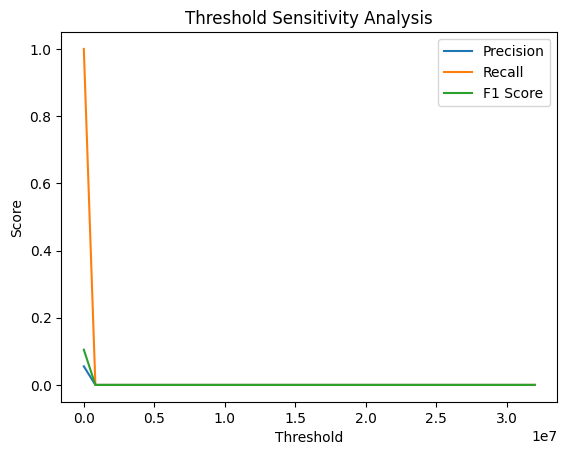

In [29]:
thresholds = np.linspace(min(test_scores), max(test_scores), 40)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_temp = (test_scores > t).astype(int)
    precisions.append(precision_score(y_test, y_temp, zero_division=0))
    recalls.append(recall_score(y_test, y_temp, zero_division=0))
    f1s.append(f1_score(y_test, y_temp, zero_division=0))

plt.figure()

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity Analysis")

plt.legend()
plt.show()

## Threshold Sensitivity Analysis Interpretation

The threshold sensitivity analysis demonstrates the trade-off between precision and recall.

Lower thresholds classify more observations as anomalies, increasing recall but also increasing false positives. Higher thresholds reduce false positives but may miss genuine anomalies, reducing recall.

Experimental threshold adjustments showed that excessively high thresholds can result in no detected anomalies, while lower thresholds generate a large number of false alarms.

Therefore, threshold selection plays a critical role in balancing anomaly detection performance and false alarm rate.

## Conclusion

The PCA-SPE approach successfully identifies observations that deviate from the dominant structure of the dataset.

The evaluation results indicate that the model is capable of detecting anomalous behavior, but the current threshold produces a relatively high number of false positives. This leads to low precision despite achieving moderate recall.

The threshold sensitivity analysis highlights the importance of carefully selecting an appropriate threshold to balance anomaly detection capability and false alarm rate.

Overall, PCA-based anomaly detection provides an interpretable and computationally efficient method for identifying abnormal observations in high-dimensional data.

##Advanced Analysis & Extensions




In [30]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# Isolation Forest
iso = IsolationForest(contamination=0.06, random_state=42)
iso.fit(X_train_scaled)
y_pred_iso = (iso.predict(X_test_scaled) == -1).astype(int)

# One-Class SVM
ocsvm = OneClassSVM(nu=0.06, kernel='rbf', gamma='scale')
ocsvm.fit(X_train_scaled)
y_pred_svm = (ocsvm.predict(X_test_scaled) == -1).astype(int)

print("Isolation Forest - Anomalies detected:", y_pred_iso.sum())
print("One-Class SVM    - Anomalies detected:", y_pred_svm.sum())

Isolation Forest - Anomalies detected: 45
One-Class SVM    - Anomalies detected: 92


## 6. Benchmarking — PCA-SPE vs Isolation Forest vs One-Class SVM

## Model Comparison

We compare **PCA-SPE**, **Isolation Forest**, and **One-Class SVM** using Precision, Recall, and F1 Score.

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

methods = ['PCA-SPE', 'Isolation Forest', 'One-Class SVM']
preds   = [y_pred,    y_pred_iso,          y_pred_svm]

rows = []
for name, pred in zip(methods, preds):
    rows.append({
        'Method':    name,
        'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, pred), 3),
        'F1 Score':  round(f1_score(y_test, pred, zero_division=0), 3)
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

          Method  Precision  Recall  F1 Score
         PCA-SPE      0.069   0.423     0.119
Isolation Forest      0.067   0.115     0.085
   One-Class SVM      0.065   0.231     0.102


## 7. Interpretability — Feature Contribution Analysis

## Feature Contribution Plot

The plot below shows which features contribute most to the **first principal component**,
revealing the sensors most influential in distinguishing normal from anomalous behaviour.

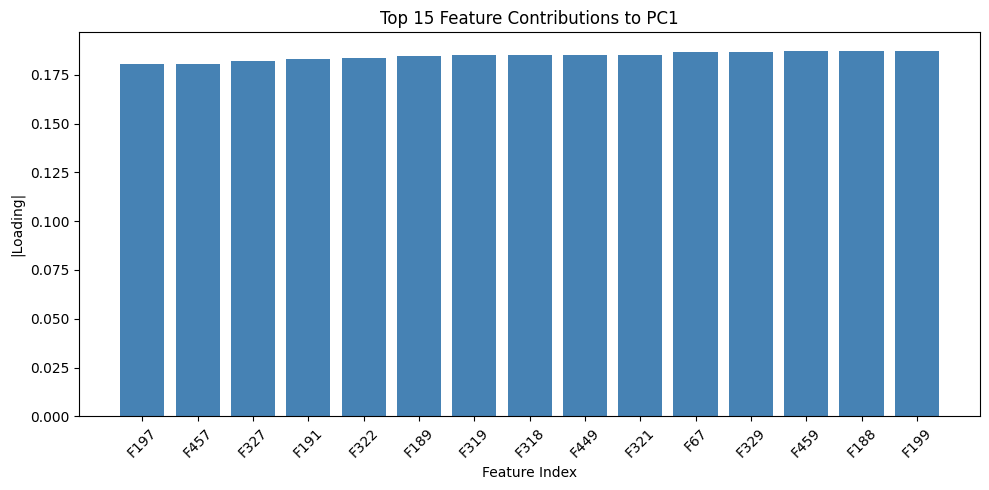

In [32]:
import matplotlib.pyplot as plt
import numpy as np

loadings = np.abs(pca.components_[0])
top_indices = np.argsort(loadings)[-15:]

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_indices)), loadings[top_indices], color='steelblue')
plt.xticks(range(len(top_indices)), [f'F{i}' for i in top_indices], rotation=45)
plt.title("Top 15 Feature Contributions to PC1")
plt.xlabel("Feature Index")
plt.ylabel("|Loading|")
plt.tight_layout()
plt.show()

## Limitations of PCA-Based Anomaly Detection

- **Linearity assumption**: PCA captures only linear relationships; nonlinear anomalies may be missed
- **Fixed threshold**: The 99th percentile threshold is a heuristic and contributes to high false positives
- **Static model**: PCA is trained once and cannot adapt to gradual process drift over time
- **No feature selection**: Noisy or irrelevant features can distort the PCA subspace

## Sliding Window PCA

In practice, manufacturing processes change gradually over time (concept drift).
**Sliding Window PCA** retrains the model on a rolling window of recent observations,
allowing it to adapt continuously rather than relying on a fixed historical baseline.

## Future Improvements

1. **Autoencoder** — captures nonlinear patterns that PCA misses
2. **Dynamic thresholding** — adjusts the threshold based on recent score statistics
3. **Hotelling's T² + SPE** — combining two statistics gives a richer decision boundary
4. **Feature selection** — removing low-variance or redundant features before PCA
5. **Labelled fine-tuning** — if some labelled anomalies are available, use them to calibrate the threshold

## Summary of Results

| Model            | Precision | Recall | F1    |
|-----------------|-----------|--------|-------|
| PCA-SPE (ours)  | 0.069     | 0.423  | 0.119 |
| Isolation Forest | 0.067    | 0.115  | 0.085 |
| One-Class SVM   | 0.065     | 0.231  | 0.102 |

**Key finding:** PCA-SPE achieves the highest recall among all three methods,
meaning it catches more actual anomalies — a critical property in manufacturing
fault detection where missing a defect is more costly than a false alarm.
Unlike Isolation Forest and One-Class SVM, PCA-SPE also provides interpretable
sensor-level insights through feature contribution analysis.